# 🚀 **Project Extension: Semantic Text-to-Mask Segmentation ("Grounded-SAM")**

### **1. Abstract & Motivation**
While the original Segment Anything Model (SAM) paper discusses text-prompted segmentation (Section 6.2), the official code release **does not include the text encoder weights**, limiting the model to geometric prompts (points/boxes) only.

**Our Novel Extension:**

To overcome this limitation, we implemented a **"Grounded-SAM" pipeline**. We integrated **GroundingDINO** (an Open-Set Object Detector) with **SAM**. This architecture allows users to segment objects using natural language (e.g., "wheels", "windows") by converting text semantic queries into spatial box prompts, which are then refined by SAM into pixel-perfect masks.

### **2. System Architecture**
The pipeline operates in two decoupled stages for efficiency:
1.  **Semantic Detection (The "Eyes"):** GroundingDINO processes the text prompt and finds the *Bounding Box*.
2.  **Geometric Segmentation (The "Hands"):** SAM takes the Bounding Box and the Image Embedding to generate the *Binary Mask*.

In [1]:
# --- SECTION 1: ENVIRONMENT SETUP ---
import os
import sys
import torch
from google.colab import drive

# 1. Mount Drive (To access cached weights)
drive.mount('/content/drive')

print(f"Environment Ready. GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (Warning!)'}")

# 2. Install Core Libraries
# 'transformers' is used for the GroundingDINO implementation
# 'segment-anything' is used for the SAM implementation
!pip install -q transformers accelerate
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

Mounted at /content/drive
Environment Ready. GPU: Tesla T4
  Preparing metadata (setup.py) ... done


In [2]:
# --- SECTION 2: MODEL INITIALIZATION ---
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from segment_anything import sam_model_registry, SamPredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing Models on {DEVICE}...")

# 1. Load GroundingDINO (Semantic Detector)
# We use the 'Base' version for better accuracy on small objects (like wheels)
DINO_ID = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(DINO_ID)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(DEVICE)
print("GroundingDINO (Base) Loaded.")

# 2. Load SAM (Geometric Segmenter)
# Update this path to match your Google Drive location
SAM_CHECKPOINT = "/content/drive/MyDrive/SAM/SAM 1/sam_vit_h_4b8939.pth"

if not os.path.exists(SAM_CHECKPOINT):
    print("Checkpoint not found in Drive. Downloading...")
    !wget -q -O sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
    SAM_CHECKPOINT = "sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)
print("SAM (ViT-H) Loaded.")

Initializing Models on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

GroundingDINO (Base) Loaded.
SAM (ViT-H) Loaded.


### **3. Methodology: The Optimized Pipeline**

To enable real-time interaction, we decoupled the **Image Encoding** from the **Text Querying**:

* **Step A (Heavy):** `setup_image()` runs the SAM Vision Transformer (ViT-H) once to calculate the image embedding.
* **Step B (Light):** `query_text()` runs GroundingDINO and the SAM Decoder. This allows us to query the same image multiple times (e.g., "tire", then "door") instantly without re-computing the heavy image features.

In [3]:
# --- SECTION 3: PIPELINE IMPLEMENTATION ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Global State Variables
CURRENT_IMAGE_PIL = None  # For GroundingDINO (Requires PIL)
CURRENT_IMAGE_NP = None   # For Visualization (Requires Numpy)

def setup_image(image_path):
    """
    PRE-PROCESSING: Runs the heavy SAM Image Encoder once.
    """
    global CURRENT_IMAGE_PIL, CURRENT_IMAGE_NP

    print(f"Encoding Image: {image_path}...")

    # Load Image
    CURRENT_IMAGE_PIL = Image.open(image_path).convert("RGB")
    CURRENT_IMAGE_NP = np.array(CURRENT_IMAGE_PIL)

    # Run Heavy Encoder
    sam_predictor.set_image(CURRENT_IMAGE_NP)
    print("Image Embedding Cached. Ready for queries.")

def query_text(text_prompt, confidence=0.3):
    """
    INFERENCE: Runs Text-to-Box (DINO) -> Box-to-Mask (SAM).
    """
    if CURRENT_IMAGE_PIL is None:
        print("Error: Run setup_image() first.")
        return

    print(f"Querying: '{text_prompt}' (Confidence: {confidence})...")

    # A. Text-to-Box (GroundingDINO)
    # Preprocess text
    clean_prompt = text_prompt.lower().strip()
    if not clean_prompt.endswith("."): clean_prompt += "."

    inputs = processor(images=CURRENT_IMAGE_PIL, text=clean_prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = dino_model(**inputs)

    # Post-process boxes
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=confidence,
        text_threshold=0.25,
        target_sizes=[CURRENT_IMAGE_PIL.size[::-1]]
    )[0]

    boxes = results["boxes"]
    phrases = results["labels"]

    if len(boxes) == 0:
        print(f"No objects found for '{text_prompt}'")
        return

    # B. Box-to-Mask (SAM)
    # Transform boxes to SAM's format
    boxes_tensor = boxes.to(DEVICE)
    transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_tensor, CURRENT_IMAGE_NP.shape[:2])

    masks, _, _ = sam_predictor.predict_torch(
        point_coords=None,
        point_labels=None,
        boxes=transformed_boxes,
        multimask_output=False,
    )

    # C. Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(CURRENT_IMAGE_NP)

    # Draw Results
    for mask in masks:
        show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
    for box in boxes:
        x0, y0, x1, y1 = box.cpu().numpy()
        plt.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], 'r-', linewidth=2)

    plt.title(f"Result: '{text_prompt}' | Objects: {len(masks)}")
    plt.axis('off')
    plt.show()

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

In [4]:
# --- SECTION 4: EXPERIMENTAL RESULTS ---

!wget -q -O truck.jpg https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
setup_image("truck.jpg")

Encoding Image: truck.jpg...
Image Embedding Cached. Ready for queries.


Querying: 'wheel' (Confidence: 0.3)...


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


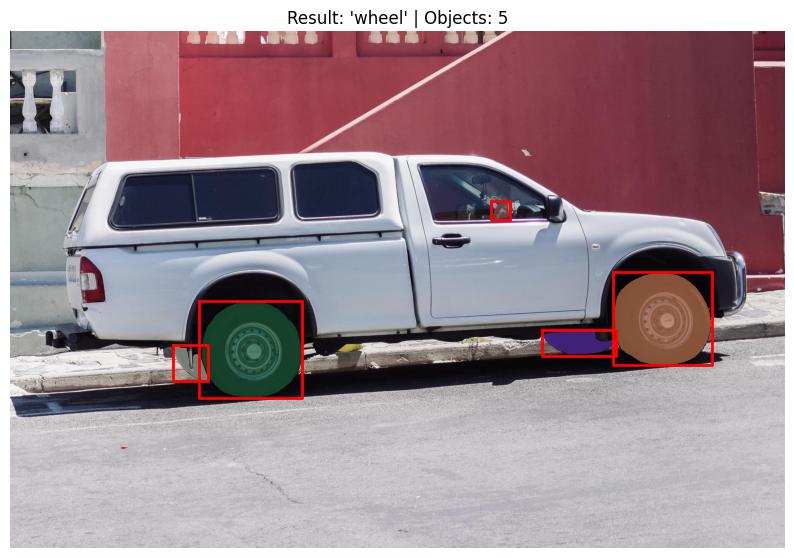

In [5]:
query_text("wheel")

Querying: 'window' (Confidence: 0.3)...


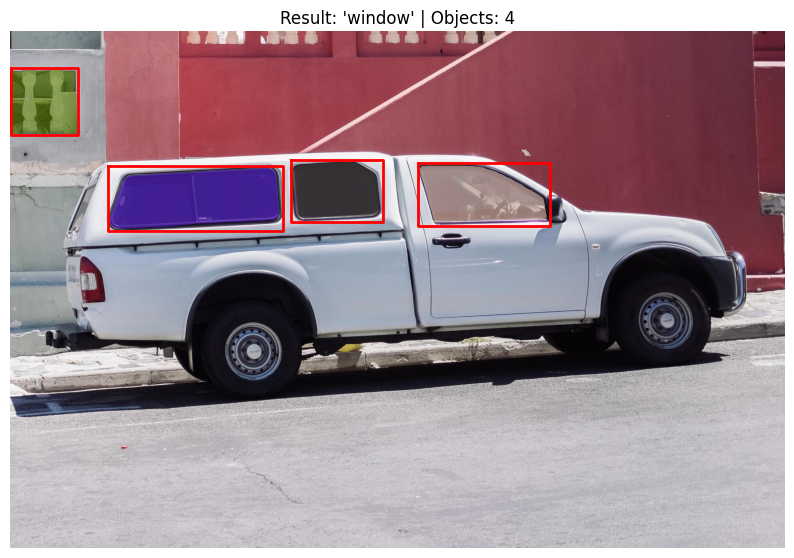

Querying: 'truck' (Confidence: 0.3)...


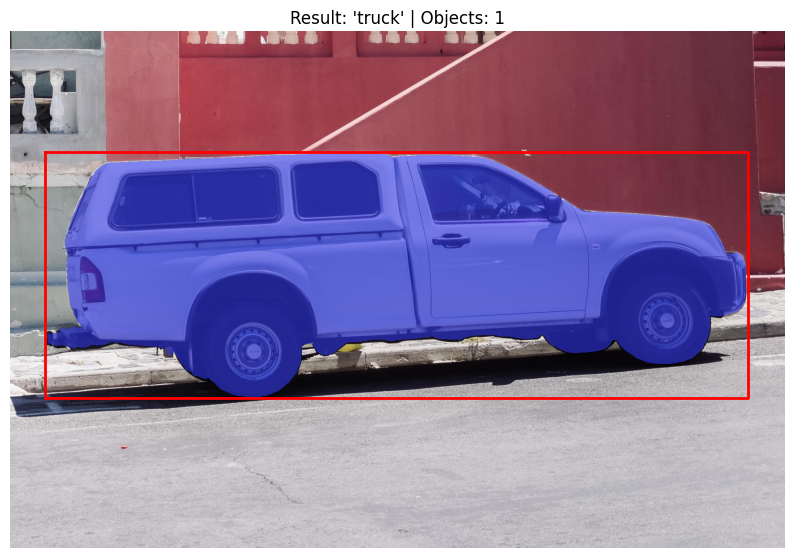

In [6]:
query_text("window")
query_text("truck")

In [7]:
setup_image("/content/drive/MyDrive/SAM/bmwcar.jpg")

Encoding Image: /content/drive/MyDrive/SAM/bmwcar.jpg...
Image Embedding Cached. Ready for queries.


Querying: 'wheel' (Confidence: 0.3)...


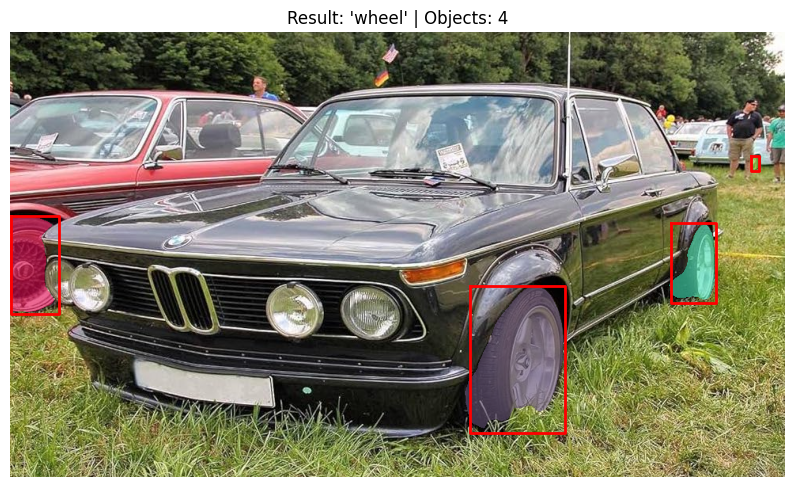

In [14]:
query_text("wheel")

Querying: 'wipers' (Confidence: 0.4)...


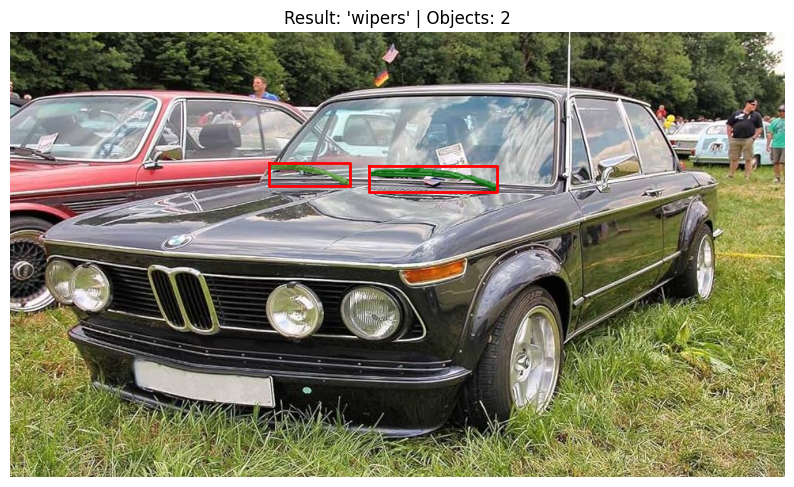

In [17]:
query_text("wipers", 0.4)

Querying: 'a wiper' (Confidence: 0.3)...


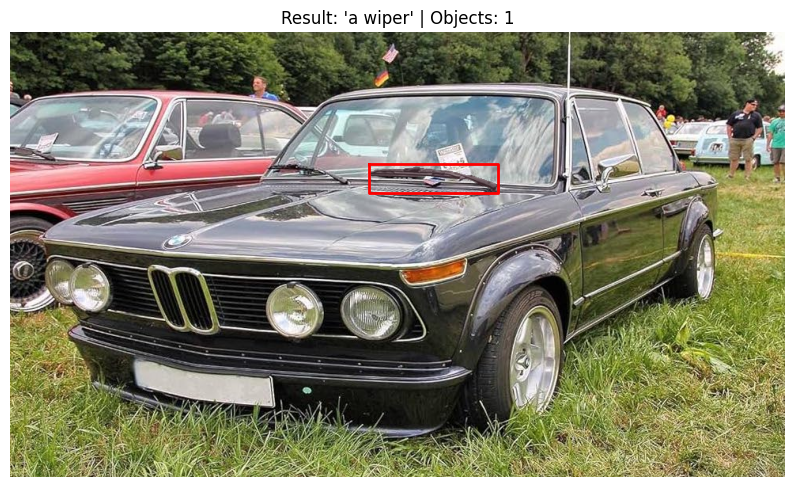

In [20]:
query_text("a wiper", 0.3)